In [27]:
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.ticker import MultipleLocator

# ==========================================================
# Helper
# ==========================================================
def load_nii(path):
    img = sitk.ReadImage(path)
    return sitk.GetArrayFromImage(img)


# ==========================================================
# VOI STATISTICS WITH RELATIVE DIFFERENCES
# ==========================================================
def statistics_multiple_vois(dose_map, voi_folder, output_txt, method_name="Method"):

    voi_files = sorted([
        f for f in os.listdir(voi_folder)
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ])

    results = []

    with open(output_txt, "w") as f:

        for voi_name in voi_files:

            voi_path = os.path.join(voi_folder, voi_name)
            voi_mask = load_nii(voi_path) > 0

            if np.count_nonzero(voi_mask) == 0:
                continue

            values = dose_map[voi_mask]

            mean_dose = np.mean(values)
            std_dose  = np.std(values)
            min_dose  = np.min(values)
            max_dose  = np.max(values)

            f.write(f"VOI: {voi_name}\n")
            f.write(f"  Voxels: {len(values)}\n")
            f.write(f"  Mean Absorbed Dose: {mean_dose:.2f}\n")  
            f.write(f"  Std: {std_dose:.2f}\n")                  
            f.write(f"  Min: {min_dose:.2f}\n")                
            f.write(f"  Max: {max_dose:.2f}\n\n")                

            results.append({
                "VOI": voi_name,
                "Voxels": len(values),
                "Mean Absorbed Dose": mean_dose,  # Store as float for calculations
                "Std": std_dose,                    # Store as float for calculations
                "Min": min_dose,
                "Max": max_dose
            })

    df = pd.DataFrame(results)
    
    # Format the output for display
    df_display = df.copy()
    df_display["Mean Absorbed Dose"] = df_display["Mean Absorbed Dose"].map("{:.2f}".format)
    df_display["Std"] = df_display["Std"].map("{:.2f}".format)
    df_display["Min"] = df_display["Min"].map("{:.2f}".format)
    df_display["Max"] = df_display["Max"].map("{:.2f}".format)

    print(f"\nStatistics saved to {output_txt}\n")
    print(f"Results for {method_name}:")
    display(df_display)

    return df


# ==========================================================
# COMPARE METHODS AND CALCULATE RELATIVE DIFFERENCES
# ==========================================================
def compare_methods(df_reconstructed, df_hu, df_vsv, output_txt="method_comparison.txt"):
    """
    Compare mean absorbed doses between different methods and calculate relative differences.
    
    Parameters:
    df_reconstructed: DataFrame with reconstructed PET statistics
    df_hu: DataFrame with Ground-truth PET statistics
    df_vsv: DataFrame with VSV statistics
    output_txt: File to save comparison results
    """
    
    # Set index to VOI for alignment
    reconstructed = df_reconstructed.set_index("VOI")
    hu = df_hu.set_index("VOI")
    vsv = df_vsv.set_index("VOI")
    
    # Get common VOIs across all three methods
    common_vois = sorted(set(reconstructed.index) & set(hu.index) & set(vsv.index))
    
    # Define desired order for main VOIs
    desired_order = [
        'nlv.nii', 
        'ptv.nii', 
        'ptv_no_necrotic.nii', 
        'WLV.nii', 
        'RWLV.nii', 
        'necrotic.nii'
    ]
    
    # Add tumour files in order
    tumour_files = sorted([f for f in common_vois if 'tumour' in f.lower() or 'tumor' in f.lower()])
    def extract_tumor_number(filename):
        numbers = ''.join(filter(str.isdigit, filename))
        return int(numbers) if numbers else 0
    tumour_files.sort(key=extract_tumor_number)
    
    # Combine in desired order
    ordered_vois = []
    for voi in desired_order:
        if voi in common_vois:
            ordered_vois.append(voi)
    ordered_vois.extend(tumour_files)
    
    # Create nicer display labels
    display_labels = []
    for voi in ordered_vois:
        if voi == 'nlv.nii':
            display_labels.append('NLV')
        elif voi == 'ptv.nii':
            display_labels.append('PTV')
        elif voi == 'ptv_no_necrotic.nii':
            display_labels.append('PTV (No Necrotic)')
        elif voi == 'WLV.nii':
            display_labels.append('WLV')
        elif voi == 'RWLV.nii':
            display_labels.append('RWLV')
        elif voi == 'necrotic.nii':
            display_labels.append('Necrotic')
        elif 'tumour' in voi.lower() or 'tumor' in voi.lower():
            tumor_num = ''.join(filter(str.isdigit, voi))
            display_labels.append(f'Tumour {tumor_num}' if tumor_num else voi.replace('.nii', ''))
        else:
            display_labels.append(voi.replace('.nii', ''))
    
    # Extract mean dose values
    reconstructed_vals = reconstructed.loc[ordered_vois, "Mean Absorbed Dose"].values
    hu_vals = hu.loc[ordered_vois, "Mean Absorbed Dose"].values
    vsv_vals = vsv.loc[ordered_vois, "Mean Absorbed Dose"].values
    
    # Calculate relative differences (%)
    # Relative difference = (method1 - method2) / method2 * 100
    rel_diff_reconstructed_vsv = (reconstructed_vals - vsv_vals) / vsv_vals * 100
    rel_diff_hu_vsv = (hu_vals - vsv_vals) / vsv_vals * 100
    rel_diff_reconstructed_hu = (hu_vals- reconstructed_vals) / ((reconstructed_vals + hu_vals)/2) * 100

    
    # Volume-weighted symmetric difference (HU vs reconstructed)
    voxel_counts = reconstructed.loc[ordered_vois, "Voxels"].values

    overall_weighted_diff = np.sum(voxel_counts * rel_diff_reconstructed_hu) / np.sum(voxel_counts)
    
    # Create comparison DataFrame
    comparison_data = []
    for i, voi in enumerate(ordered_vois):
        comparison_data.append({
            "VOI": display_labels[i],
            "Reconstructed PET (Gy)": f"{reconstructed_vals[i]:.2f}",
            "Ground-truth PET (Gy)": f"{hu_vals[i]:.2f}",
            "VSV (Gy)": f"{vsv_vals[i]:.2f}",
            "Reconstructed PET vs VSV (%)": f"{rel_diff_reconstructed_vsv[i]:.2f}",
            "HU vs VSV (%)": f"{rel_diff_hu_vsv[i]:.2f}",
            "reconstructed PET vs Ground-truth PET (%)": f"{rel_diff_reconstructed_hu[i]:.2f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Save to text file
    with open(output_txt, "w") as f:
        f.write("="*100 + "\n")
        f.write("COMPARISON OF MEAN ABSORBED DOSES BETWEEN METHODS\n")
        f.write("="*100 + "\n\n")
        
        f.write("Absolute Values (Gy):\n")
        f.write("-"*50 + "\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: Reconstructed={reconstructed_vals[i]:.2f}, HU={hu_vals[i]:.2f}, VSV={vsv_vals[i]:.2f}\n")
        
        f.write("\nRelative Differences (%):\n")
        f.write("-"*50 + "\n")
        f.write("(Positive means method has higher dose than reference)\n\n")
        
        f.write("Reconstructed PET vs VSV:\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: {rel_diff_reconstructed_vsv[i]:+.2f}%\n")
        
        f.write("\nGround-Truth PET vs VSV:\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: {rel_diff_hu_vsv[i]:+.2f}%\n")
        
        f.write("\nReconstructed PET vs Ground-truth PET:\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: {rel_diff_reconstructed_hu[i]:+.2f}%\n")
        
        # Calculate summary statistics
        f.write("\n" + "="*100 + "\n")
        f.write("SUMMARY STATISTICS\n")
        f.write("="*100 + "\n")
        
        f.write("\nReconstructed vs VSV relative differences (%):\n")
        f.write(f"  Mean: {np.mean(rel_diff_reconstructed_vsv):+.2f}%\n")
        f.write(f"  Std:  {np.std(rel_diff_reconstructed_vsv):.2f}%\n")
        f.write(f"  Min:  {np.min(rel_diff_reconstructed_vsv):+.2f}%\n")
        f.write(f"  Max:  {np.max(rel_diff_reconstructed_vsv):+.2f}%\n")
        f.write(f"  |Diff| < 5%: {np.sum(np.abs(rel_diff_reconstructed_vsv) < 5)}/{len(rel_diff_reconstructed_vsv)} VOIs\n")
        
        f.write("\nGround-truth PET vs VSV relative differences (%):\n")
        f.write(f"  Mean: {np.mean(rel_diff_hu_vsv):+.2f}%\n")
        f.write(f"  Std:  {np.std(rel_diff_hu_vsv):.2f}%\n")
        f.write(f"  Min:  {np.min(rel_diff_hu_vsv):+.2f}%\n")
        f.write(f"  Max:  {np.max(rel_diff_hu_vsv):+.2f}%\n")
        f.write(f"  |Diff| < 5%: {np.sum(np.abs(rel_diff_hu_vsv) < 5)}/{len(rel_diff_hu_vsv)} VOIs\n")
        
        f.write("\nReconstructed vs Ground-truth PET differences (%):\n")
        f.write(f"  Mean: {np.mean(rel_diff_reconstructed_hu):+.2f}%\n")
        f.write(f"  Std:  {np.std(rel_diff_reconstructed_hu):.2f}%\n")
        f.write(f"  Min:  {np.min(rel_diff_reconstructed_hu):+.2f}%\n")
        f.write(f"  Max:  {np.max(rel_diff_reconstructed_hu):+.2f}%\n")
        f.write(f"  |Diff| < 5%: {np.sum(np.abs(rel_diff_reconstructed_hu) < 5)}/{len(rel_diff_reconstructed_hu)} VOIs\n")

        f.write("\nVolume-Weighted Overall Difference (HU vs reconstructed):\n")
        f.write(f"  {overall_weighted_diff:+.2f}%\n")

    
    print(f"\nComparison saved to {output_txt}\n")
    print("Relative Differences Between Methods:")
    display(comparison_df)
    
    return comparison_df, rel_diff_reconstructed_vsv, rel_diff_hu_vsv, rel_diff_reconstructed_hu, ordered_vois, display_labels, overall_weighted_diff


# ==========================================================
# Plot style
# ==========================================================
def setup_latex():
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 28,
        "axes.labelsize": 28,
        "legend.fontsize": 23,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "axes.linewidth": 1.5,
        "lines.linewidth": 3,
    })

# ==========================================================
# DVH FOR MAIN VOIs
# ==========================================================
def combined_dvh_main_vois(ax, vsv_dose_path, mc_dose_path, voi_folder):

    vsv = load_nii(vsv_dose_path)
    mc  = load_nii(mc_dose_path)

    voi_list = [
        'nlv.nii',
        'ptv.nii',
        'ptv_no_necrotic.nii',
        'WLV.nii',
        'RWLV.nii',
        'necrotic.nii'
    ]

    voi_labels = {
        "nlv.nii": "NLV",
        "ptv.nii": "PTV",
        "ptv_no_necrotic.nii": "PTV (No Necrotic)",
        "WLV.nii": "WLV",
        "RWLV.nii": "RWLV",
        "necrotic.nii": "Necrotic"
    }

    existing_vois = [
        v for v in voi_list if os.path.exists(os.path.join(voi_folder, v))
    ]

    colors = [
        (31/255,119/255,180/255),
        (255/255,160/255,70/255), 
        (44/255,160/255,44/255),
        (214/255,39/255,40/255),
        (148/255,103/255,189/255),
        (140/255,86/255,75/255),
    ]

    global_max_dose = 0
    dose_data = []

    for voi_name in existing_vois:
        voi_mask = load_nii(os.path.join(voi_folder, voi_name)) > 0
        dose_vsv = vsv[voi_mask]
        dose_mc  = mc[voi_mask]

        if len(dose_vsv)>0: global_max_dose=max(global_max_dose,dose_vsv.max())
        if len(dose_mc)>0:  global_max_dose=max(global_max_dose,dose_mc.max())

        dose_data.append((voi_name,dose_vsv,dose_mc))

    x_limit=max(610,global_max_dose*1.05)
    bins=np.linspace(0,x_limit,200)

    for idx,(voi_name,dose_vsv,dose_mc) in enumerate(dose_data):

        color=colors[idx%len(colors)]
        if len(dose_vsv)==0 or len(dose_mc)==0:
            continue

        hist_vsv,edges=np.histogram(dose_vsv,bins=bins)
        cum_vsv=np.cumsum(hist_vsv[::-1])[::-1]
        rel_vsv=100.0*cum_vsv/cum_vsv[0]

        hist_mc,_=np.histogram(dose_mc,bins=bins)
        cum_mc=np.cumsum(hist_mc[::-1])[::-1]
        rel_mc=100.0*cum_mc/cum_mc[0]

        display_name=voi_labels.get(voi_name,voi_name)

        ax.plot(edges[:-1],rel_mc,color=color,linewidth=2,
                label=f"{display_name} (MC)")
        ax.plot(edges[:-1],rel_vsv,'--',color=color,linewidth=1.5,
                label=f"{display_name} (VSV)",alpha=0.8)

    ax.set_xlabel("Absorbed Dose (Gy)",labelpad=16)
    ax.set_ylabel(r"Volume ($\%$)")

    ax.set_ylim(0,105)
    ax.set_xlim(0,x_limit)

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.grid(True,alpha=0.3)

    ax.legend(frameon=True,edgecolor='black',fontsize=15,loc='upper right')


# ==========================================================
# DVH FOR TUMORS
# ==========================================================
def combined_dvh_tumors(ax, vsv_dose_path, mc_dose_path, voi_folder):

    vsv=load_nii(vsv_dose_path)
    mc=load_nii(mc_dose_path)

    tumor_files=[f for f in os.listdir(voi_folder)
        if (f.endswith(".nii") or f.endswith(".nii.gz"))
        and ("tumour" in f.lower() or "tumor" in f.lower())]

    def extract_tumor_number(filename):
        numbers=''.join(filter(str.isdigit,filename))
        return int(numbers) if numbers else 0

    tumor_files.sort(key=extract_tumor_number)

    from matplotlib.cm import tab20
    colors=[tab20(i) for i in range(len(tumor_files))]

    global_max_dose=0
    dose_data=[]

    for voi_name in tumor_files:
        voi_mask=load_nii(os.path.join(voi_folder,voi_name))>0
        dose_vsv=vsv[voi_mask]
        dose_mc=mc[voi_mask]

        if len(dose_vsv)>0: global_max_dose=max(global_max_dose,dose_vsv.max())
        if len(dose_mc)>0:  global_max_dose=max(global_max_dose,dose_mc.max())

        dose_data.append((voi_name,dose_vsv,dose_mc))

    x_limit=max(620,global_max_dose*1.05)
    bins=np.linspace(0,x_limit,200)

    for idx,(voi_name,dose_vsv,dose_mc) in enumerate(dose_data):

        color=colors[idx%len(colors)]
        if len(dose_vsv)==0 or len(dose_mc)==0:
            continue

        hist_vsv,edges=np.histogram(dose_vsv,bins=bins)
        cum_vsv=np.cumsum(hist_vsv[::-1])[::-1]
        rel_vsv=100.0*cum_vsv/cum_vsv[0]

        hist_mc,_=np.histogram(dose_mc,bins=bins)
        cum_mc=np.cumsum(hist_mc[::-1])[::-1]
        rel_mc=100.0*cum_mc/cum_mc[0]

        tumor_num=''.join(filter(str.isdigit,voi_name))
        display_name=f"Tumour {tumor_num}" if tumor_num else voi_name

        ax.plot(edges[:-1],rel_mc,color=color,linewidth=2,
                label=f"{display_name} (MC)")
        ax.plot(edges[:-1],rel_vsv,'--',color=color,linewidth=1.5,
                label=f"{display_name} (VSV)",alpha=0.8)

    ax.set_xlabel("Absorbed Dose (Gy)",labelpad=16)

    ax.set_ylim(0,105)
    ax.set_xlim(0,x_limit)

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.grid(True,alpha=0.3)

    ax.legend(frameon=True,edgecolor='black',fontsize=11.6,loc='upper right')

# ==========================================================
# DOSE BAR PLOT WITH STANDARD DEVIATION ERROR BARS
# ==========================================================
def dose_barplot_latex(df_hu, df_reconstructed, df_vsv, use_intersection=True):
    """
    Create a bar plot comparing mean absorbed doses from three different methods
    with error bars representing the standard deviation.
    
    Parameters:
    df_hu: DataFrame with ground-truth pet statistics (includes Std column)
    df_reconstructed: DataFrame with reconstructed pet statistics (includes Std column)
    df_vsv: DataFrame with VSV statistics (includes Std column)
    use_intersection: If True, use only VOIs present in all three DataFrames
    """
    setup_latex()

    # Define the color palette inside the function
    # RGB tuples (0–255)
    palette_rgb = [
        (20, 144, 228),   # blue
        (0, 94, 94),      # teal
        (159, 25, 85),    # dark magenta
        (252, 79, 88),    # pink-red
        (250, 78, 86)     # red
    ]

    # Index by VOI for alignment
    hu = df_hu.set_index("VOI")
    dg = df_reconstructed.set_index("VOI")
    vs = df_vsv.set_index("VOI")

    if use_intersection:
        common = sorted(set(hu.index) & set(dg.index) & set(vs.index))
    else:
        # union (will produce NaNs if missing)
        common = sorted(set(hu.index) | set(dg.index) | set(vs.index))
    
    # Define the desired order of VOIs
    desired_order = [
        'nlv.nii', 
        'ptv.nii', 
        'ptv_no_necrotic.nii', 
        'WLV.nii', 
        'RWLV.nii', 
        'necrotic.nii'
    ]
    
    # Add tumour files in order
    tumour_files = sorted([f for f in common if 'tumour' in f.lower() or 'tumor' in f.lower()])
    # Sort tumour files by number
    def extract_tumor_number(filename):
        numbers = ''.join(filter(str.isdigit, filename))
        return int(numbers) if numbers else 0
    tumour_files.sort(key=extract_tumor_number)
    
    # Combine in desired order: main VOIs first, then tumours
    ordered_vois = []
    for voi in desired_order:
        if voi in common:
            ordered_vois.append(voi)
    
    # Add all tumour files
    ordered_vois.extend(tumour_files)
    
    # Use the ordered list instead of 'common'
    common = ordered_vois

    # Convert string values back to float for plotting
    hu_vals = pd.to_numeric(hu.loc[common, "Mean Absorbed Dose"]).to_numpy()
    dg_vals = pd.to_numeric(dg.loc[common, "Mean Absorbed Dose"]).to_numpy()
    vs_vals = pd.to_numeric(vs.loc[common, "Mean Absorbed Dose"]).to_numpy()
    
    # Get standard deviation values for error bars
    hu_std = pd.to_numeric(hu.loc[common, "Std"]).to_numpy()
    dg_std = pd.to_numeric(dg.loc[common, "Std"]).to_numpy()
    vs_std = pd.to_numeric(vs.loc[common, "Std"]).to_numpy()

    # Create nicer labels for display
    display_labels = []
    for voi in common:
        if voi == 'nlv.nii':
            display_labels.append('NLV')
        elif voi == 'ptv.nii':
            display_labels.append('PTV')
        elif voi == 'ptv_no_necrotic.nii':
            display_labels.append('PTV (No Necrotic)')
        elif voi == 'WLV.nii':
            display_labels.append('WLV')
        elif voi == 'RWLV.nii':
            display_labels.append('RWLV')
        elif voi == 'necrotic.nii':
            display_labels.append('Necrotic')
        elif 'tumour' in voi.lower() or 'tumor' in voi.lower():
            tumor_num = ''.join(filter(str.isdigit, voi))
            display_labels.append(f'Tumour {tumor_num}' if tumor_num else voi.replace('.nii', ''))
        else:
            display_labels.append(voi.replace('.nii', ''))

    # SPACING BETWEEN VOI GROUPS
    spacing_factor = 1.8
    x = np.arange(len(common)) * spacing_factor
    
    # Adjust bar width to maintain proportions with increased spacing
    width = 0.4  # Slightly wider bars to compensate for increased spacing

    # Fig size - slightly wider to accommodate increased spacing
    fig, ax = plt.subplots(figsize=(28, 13))  # Increased from 26 to 28

    # Convert RGB tuples (0-255) to matplotlib format (0-1)
    palette = [(r/255, g/255, b/255) for r, g, b in palette_rgb]
    
    # Assign colors from your palette in the desired order
    c_reconstructed = palette[2]  # dark magenta for reconstructed pet
    c_hu = palette[0]        # blue for real pet
    c_vsv = palette[1]       # teal for VSV

    # Set grid to be behind by using low zorder
    ax.grid(True, alpha=0.3, zorder=0)
    
    # Reconstructed CASToR, PET real (middle), VSV (right)
    # Set higher zorder so bars appear in front of grid
    bars1 = ax.bar(x - width, dg_vals, width, label="Reconstructed PET", color=c_reconstructed, zorder=3)
    bars2 = ax.bar(x, hu_vals, width, label="Ground-truth PET", color=c_hu, zorder=3)
    bars3 = ax.bar(x + width, vs_vals, width, label="VSV", color=c_vsv, zorder=3)
    
    # Error bars for all three methods using standard deviation
    # Scale the error bars if needed by multiplying the std values
    error_scale = 0.4 
    
    # Error bars for castor reconstucted
    ax.errorbar(x - width, dg_vals, yerr=dg_std * error_scale, fmt='o', 
                ecolor='black', capsize=4, capthick=2, marker='o', markersize=4, elinewidth=2, markerfacecolor='black', markeredgecolor='black', zorder=4)
    
    # Error bars for real pet
    ax.errorbar(x, hu_vals, yerr=hu_std * error_scale, fmt='o', 
                ecolor='black', capsize=4, capthick=2, marker='o', markersize=4, elinewidth=2, markerfacecolor='black', markeredgecolor='black', zorder=4)
    
    # Error bars for VSV
    ax.errorbar(x + width, vs_vals, yerr=vs_std * error_scale, fmt='o', 
                ecolor='black', capsize=4, capthick=2, marker='o', markersize=4, elinewidth=2, markerfacecolor='black', markeredgecolor='black', zorder=4)


    ax.set_ylabel("Absorbed Dose (Gy)", labelpad=16, fontsize=33)
    ax.set_xlabel("VOI", labelpad=16, fontsize=33)

    ax.set_xticks(x)
    ax.set_xticklabels(display_labels, rotation=45, ha='right')

    # Increase tick label sizes
    ax.tick_params(axis='x', labelsize=33)
    ax.tick_params(axis='y', labelsize=33)

    # Add some padding on the sides
    ax.set_xlim(x[0] - width*2, x[-1] + width*2)

    ax.legend(frameon=True, edgecolor="black", loc="upper left", fontsize=33)

    plt.tight_layout()
    return fig, ax

Calculating statistics for VSV...

Statistics saved to /home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/VSV_stats.txt

Results for VSV:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,49.83,84.46,0.00,609.75
1,Tumour1.nii,350,466.40,55.73,389.79,609.75
2,Tumour2.nii,932,449.39,45.77,389.52,600.50
3,Tumour3.nii,221,426.82,22.31,390.54,487.19
4,Tumour4.nii,469,427.76,27.87,389.65,524.22
5,Tumour5.nii,132,441.93,39.53,389.53,539.37
6,Tumour6.nii,42,434.63,30.39,392.39,505.46
7,Tumour7.nii,19,410.31,12.59,390.50,435.64
8,Tumour8.nii,107,420.75,19.97,389.68,468.35
9,WLV.nii,195696,68.18,96.86,0.00,609.75



Calculating statistics for PET original HU...

Statistics saved to /home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/HU_stats.txt

Results for Ground-truth PET:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,46.49,84.96,0.00,601.21
1,Tumour1.nii,350,463.61,55.43,379.46,601.21
2,Tumour2.nii,932,449.54,45.64,378.18,601.19
3,Tumour3.nii,221,431.38,23.20,388.49,488.42
4,Tumour4.nii,469,430.64,28.07,384.13,526.38
5,Tumour5.nii,132,438.46,39.44,379.82,537.33
6,Tumour6.nii,42,433.26,31.39,387.66,514.07
7,Tumour7.nii,19,408.38,12.60,385.34,431.00
8,Tumour8.nii,107,418.49,19.98,387.06,469.63
9,WLV.nii,195696,67.53,96.77,0.00,601.21



Calculating statistics for CASToR reconstructed...

Statistics saved to /home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/Reconstructed_stats.txt

Results for Reconstructed PET:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,45.43,75.80,0.00,588.06
1,Tumour1.nii,350,430.97,62.14,321.64,588.06
2,Tumour2.nii,932,396.47,44.79,307.51,529.40
3,Tumour3.nii,221,380.10,31.11,304.00,455.27
4,Tumour4.nii,469,377.03,35.79,297.55,468.96
5,Tumour5.nii,132,387.65,37.59,319.04,479.61
6,Tumour6.nii,42,397.81,33.65,346.50,479.18
7,Tumour7.nii,19,346.15,13.10,324.39,365.55
8,Tumour8.nii,107,390.45,21.43,341.42,433.32
9,WLV.nii,195696,66.36,84.87,0.00,588.06



COMPARING METHODS - RELATIVE DIFFERENCES

Comparison saved to /home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/method_comparison.txt

Relative Differences Between Methods:


,VOI,Reconstructed PET (Gy),Ground-truth PET (Gy),VSV (Gy),Reconstructed PET vs VSV (%),HU vs VSV (%),reconstructed PET vs Ground-truth PET (%)
0,NLV,51.24,51.73,53.54,-4.31,-3.38,0.96
1,PTV,93.03,95.25,95.94,-3.03,-0.71,2.36
2,PTV (No Necrotic),108.42,113.91,114.80,-5.55,-0.77,4.94
3,WLV,66.36,67.53,68.18,-2.67,-0.95,1.75
4,RWLV,45.43,46.49,49.83,-8.84,-6.70,2.32
5,Necrotic,40.06,31.03,31.02,29.15,0.05,-25.39
6,Tumour 1,430.97,463.61,466.40,-7.60,-0.60,7.30
7,Tumour 2,396.47,449.54,449.39,-11.78,0.03,12.55
8,Tumour 3,380.10,431.38,426.82,-10.95,1.07,12.64
9,Tumour 4,377.03,430.64,427.76,-11.86,0.67,13.27



Volume-Weighted Overall Difference (PET Real vs CASToR reconstructed): +1.61%

CREATING BAR PLOT...


/tmp/ipykernel_20140/3644444498.py:547: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x - width, dg_vals, yerr=dg_std * error_scale, fmt='o',
/tmp/ipykernel_20140/3644444498.py:551: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x, hu_vals, yerr=hu_std * error_scale, fmt='o',
/tmp/ipykernel_20140/3644444498.py:555: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x + width, vs_vals, yerr=vs_std * error_scale, fmt='o',


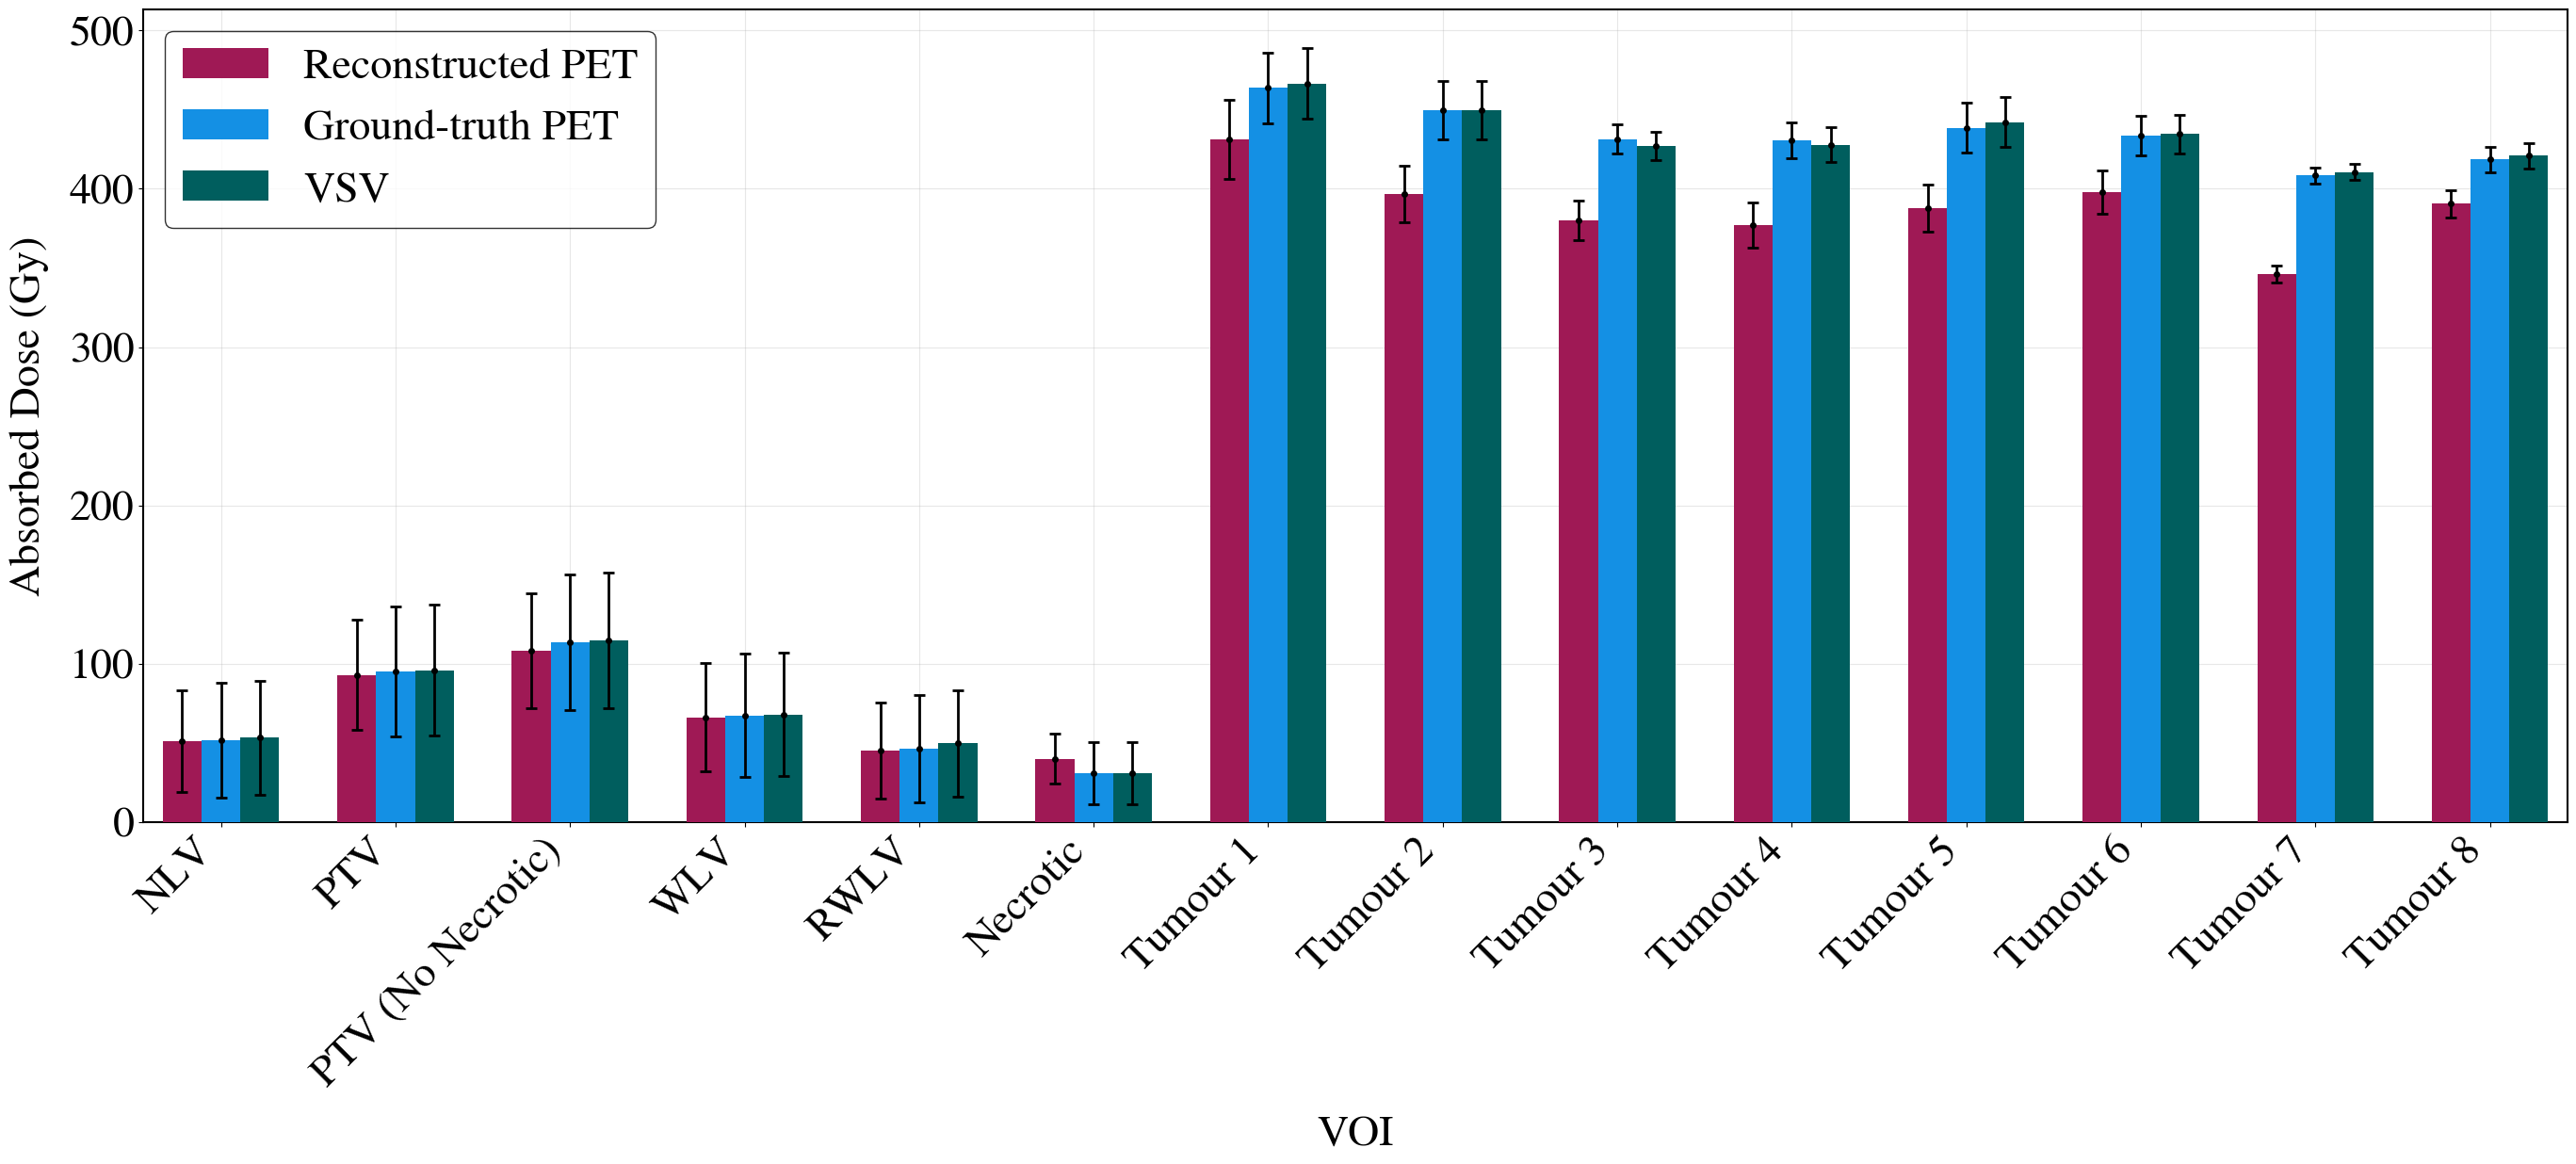


Analysis complete!


In [28]:
# ==========================================================
# MAIN
# ==========================================================
if __name__ == "__main__":

    setup_latex()

    vsv_dose_path = "/home/administrator/Champalimaud dados/Imagens/ab_dose_y90.nii"
    mc_dose_path_hu = "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_Dosimetry_Simulation_CTPhantom_1.18e8/Patient_ADD_MCdosimetry_ctphantom118e8.nii.gz"
    mc_dose_path_reconstructed = "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/Patient_ADD_MCdosimetry_ctphantom118e8_reconstrutedFinal3239.nii.gz"
    voi_folder = "/home/administrator/Secretária/Results_MC_Dosimetry/VOIs"

    # Compute stats and KEEP the returned dataframes
    print("="*60)
    print("Calculating statistics for VSV...")
    print("="*60)
    df_vsv = statistics_multiple_vois(load_nii(vsv_dose_path), voi_folder, "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/VSV_stats.txt", "VSV")
    
    print("\n" + "="*60)
    print("Calculating statistics for PET original HU...")
    print("="*60)
    df_hu = statistics_multiple_vois(load_nii(mc_dose_path_hu), voi_folder, "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/HU_stats.txt", "Ground-truth PET")
    
    print("\n" + "="*60)
    print("Calculating statistics for CASToR reconstructed...")
    print("="*60)
    df_reconstructed = statistics_multiple_vois(load_nii(mc_dose_path_reconstructed), voi_folder, "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/Reconstructed_stats.txt", "Reconstructed PET")

    # ==========================================================
    # COMPARE METHODS AND CALCULATE RELATIVE DIFFERENCES
    # ==========================================================
    print("\n" + "="*60)
    print("COMPARING METHODS - RELATIVE DIFFERENCES")
    print("="*60)
    
    comparison_df, rel_diff_reconstructed_vsv, rel_diff_hu_vsv, rel_diff_reconstructed_hu, vois, labels, overall_weighted_diff = compare_methods(
        df_reconstructed, df_hu, df_vsv, "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/method_comparison.txt"
    )

    print("\nVolume-Weighted Overall Difference (PET Real vs CASToR reconstructed): "
      f"{overall_weighted_diff:+.2f}%")

    # Plot with standard deviation error bars for all methods
    print("\n" + "="*60)
    print("CREATING BAR PLOT...")
    print("="*60)
    fig, ax = dose_barplot_latex(df_hu, df_reconstructed, df_vsv)

    plt.show()

    fig.savefig(
    "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/dosebarplot.png",
    dpi=600,
    bbox_inches="tight"
)
    
    print("\nAnalysis complete!")

=== VSV Statistics ===

Statistics saved to /home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/VSV_stats.txt

Results for Method:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,49.83,84.46,0.00,609.75
1,Tumour1.nii,350,466.40,55.73,389.79,609.75
2,Tumour2.nii,932,449.39,45.77,389.52,600.50
3,Tumour3.nii,221,426.82,22.31,390.54,487.19
4,Tumour4.nii,469,427.76,27.87,389.65,524.22
5,Tumour5.nii,132,441.93,39.53,389.53,539.37
6,Tumour6.nii,42,434.63,30.39,392.39,505.46
7,Tumour7.nii,19,410.31,12.59,390.50,435.64
8,Tumour8.nii,107,420.75,19.97,389.68,468.35
9,WLV.nii,195696,68.18,96.86,0.00,609.75



=== MC Statistics ===

Statistics saved to /home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/MC_stats.txt

Results for Method:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,45.43,75.80,0.00,588.06
1,Tumour1.nii,350,430.97,62.14,321.64,588.06
2,Tumour2.nii,932,396.47,44.79,307.51,529.40
3,Tumour3.nii,221,380.10,31.11,304.00,455.27
4,Tumour4.nii,469,377.03,35.79,297.55,468.96
5,Tumour5.nii,132,387.65,37.59,319.04,479.61
6,Tumour6.nii,42,397.81,33.65,346.50,479.18
7,Tumour7.nii,19,346.15,13.10,324.39,365.55
8,Tumour8.nii,107,390.45,21.43,341.42,433.32
9,WLV.nii,195696,66.36,84.87,0.00,588.06


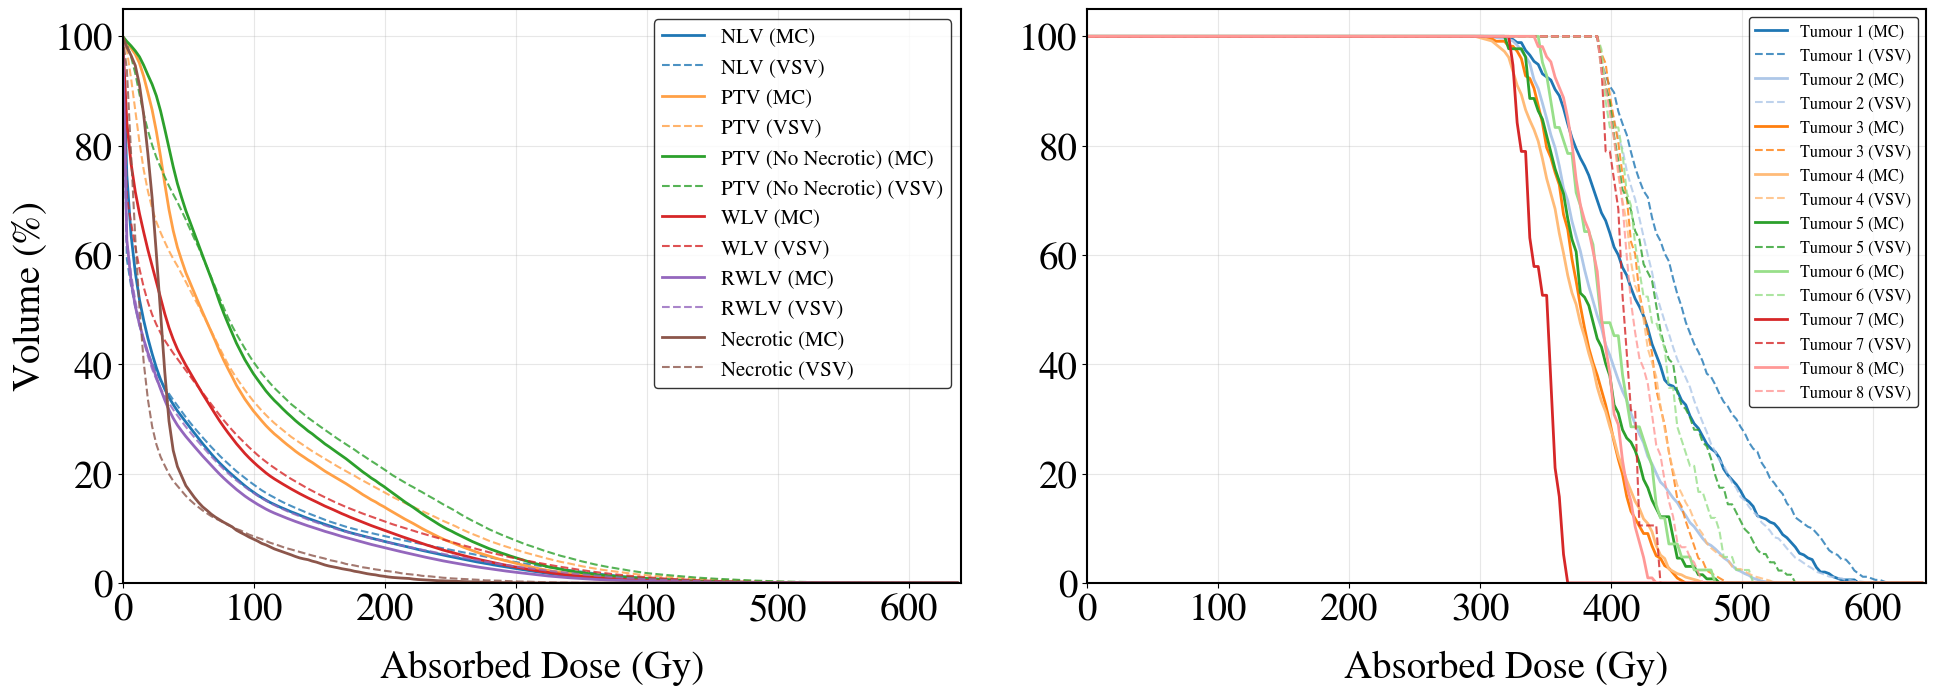

In [29]:
# ==========================================================
# MAIN EXECUTION
# ==========================================================
if __name__ == "__main__":

    setup_latex()

    vsv_dose_path="/home/administrator/Champalimaud dados/Imagens/ab_dose_y90.nii"
    mc_dose_path="/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/Patient_ADD_MCdosimetry_ctphantom118e8_reconstrutedFinal3239.nii.gz"
    voi_folder="/home/administrator/Secretária/Results_MC_Dosimetry/VOIs"

    print("=== VSV Statistics ===")
    statistics_multiple_vois(load_nii(vsv_dose_path),voi_folder,"/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/VSV_stats.txt")

    print("\n=== MC Statistics ===")
    statistics_multiple_vois(load_nii(mc_dose_path),voi_folder,"/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/MC_stats.txt")

    # ======================================================
    # SIDE-BY-SIDE DVH WITH SHARED TITLE
    # ======================================================
    fig,axes=plt.subplots(1,2,figsize=(20,8))

    combined_dvh_main_vois(axes[0],vsv_dose_path,mc_dose_path,voi_folder)
    combined_dvh_tumors(axes[1],vsv_dose_path,mc_dose_path,voi_folder)

    # ===== SHARED GLOBAL TITLE =====
    #fig.suptitle("HU Phantom", fontsize=24, y=0.91)

    plt.tight_layout(rect=[0,0,1,0.95])
    fig.subplots_adjust(wspace=0.15)
    plt.savefig(
    "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_PETReconstructedCF_RescalesplesPhilips-20260310T090212Z-1-001/outputfinalCF/petreconstructedDVH.png",
    dpi=600,              # VERY high quality
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
    plt.show()

In [ ]:
import numpy as np
import nibabel as nib

pet_path = "/home/administrator/Champalimaud dados/Imagens/pet_y90.nii"
mask_path = "/home/administrator/Champalimaud dados/Imagens/liver.nii"

pet_img = nib.load(pet_path)
pet_data = pet_img.get_fdata()

mask_img = nib.load(mask_path)
mask = mask_img.get_fdata() > 0

# voxel size
dx, dy, dz = pet_img.header.get_zooms()[:3]

# voxel volume mL
voxel_volume_ml = (dx * dy * dz) / 1000

# extract liver voxels
voi_values = pet_data[mask]

# convert to MBq/mL
voi_values_MBqml = voi_values / 100

# compute activity
activity_MBq = np.sum(voi_values_MBqml) * voxel_volume_ml

print("Total liver activity (MBq):", activity_MBq)

Total liver activity (MBq): 165.2298655398995
